# Accuracy vs. TTFT: Transformer, SSM, and Hybrid Architectures

This notebook visualizes **benchmark accuracy** and **Time to First Token (TTFT)** for three language model architectures at approximately 1.5B parameters:

- **Qwen2.5-1.5B** — a Transformer-based model
- **Mamba2-1.3B** — a State Space Model (SSM)
- **Falcon-H1-1.5B** — a Hybrid SSM-Transformer model

Accuracy is evaluated across five standard NLP benchmarks. TTFT is measured at a long context of ~57k tokens to highlight inference latency differences.

### Key observations
- **Accuracy**: Qwen2.5-1.5B and Falcon-H1-1.5B achieve comparable scores across most tasks. Mamba2-1.3B trails on knowledge-intensive benchmarks (MMLU, ARC-C) but remains competitive on commonsense reasoning tasks.
- **TTFT**: Mamba2-1.3B is dramatically faster at long context (1.35 s vs. 8.24 s for Qwen2.5-1.5B), demonstrating the linear-time prefill advantage of SSMs. Falcon-H1-1.5B strikes a middle ground at 2.95 s, reflecting its hybrid design.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
prof_dir = "."

## Benchmark Data

Accuracy scores (%) from standard zero-shot or few-shot evaluations across five benchmarks:

| Benchmark | Description |
|-----------|-------------|
| **MMLU** | Massive Multitask Language Understanding — broad knowledge across 57 subjects |
| **HellaSwag** | Commonsense NLI — sentence completion requiring situational reasoning |
| **Winogrande** | Commonsense reasoning via pronoun resolution |
| **ARC-C** | AI2 Reasoning Challenge (Challenge set) — science questions requiring multi-step inference |
| **TruthfulQA** | Measures tendency to reproduce common human misconceptions |

TTFT values (seconds) are collected from single-request inference runs on a single GPU at ~57,000 tokens of input context.

In [3]:
# 1. Prepare the Data
# -------------------
data = {
    'Model': [
        'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B', 'Qwen2.5-1.5B',
        'Mamba2-1.3B', 'Mamba2-1.3B', 'Mamba2-1.3B', 'Mamba2-1.3B', 'Mamba2-1.3B',
        'Falcon-H1-1.5B', 'Falcon-H1-1.5B', 'Falcon-H1-1.5B', 'Falcon-H1-1.5B', 'Falcon-H1-1.5B'
    ],
    'Task': [
        'MMLU', 'HellaSwag', 'Winogrande', 'ARC-C', 'TruthfulQA',
        'MMLU', 'HellaSwag', 'Winogrande', 'ARC-C', 'TruthfulQA',
        'MMLU', 'HellaSwag', 'Winogrande', 'ARC-C', 'TruthfulQA'
    ],
    'Accuracy': [
        61.13, 67.86, 64.56, 54.27, 47.05,  # Qwen (Transformer)
        36.3, 59.48, 58.72, 33.2, 36.1,   # Mamba2 (SSM)
        61.81, 66.76, 65.59, 53.24, 49.39    # FalconH1 (Hybrid)
    ]
}

df = pd.DataFrame(data)

# Prefill latency for high sequence length for the line chart (sec @ 57k context)
models_unique = ['Qwen2.5-1.5B', 'Mamba2-1.3B', 'Falcon-H1-1.5B']
ttft_vals = [8.24, 1.35, 2.95]

## Visualization — Annotated Chart

The dual-axis chart below shows:
- **Left axis (bars)**: accuracy (%) grouped by benchmark task for each model architecture.
- **Right axis (dashed line)**: TTFT (seconds) at ~57k tokens of input context.

Exact TTFT values are annotated directly on the line markers.

Text(0.5, 1.0, 'Model Accuracy vs TTFT (57k Sequence Length)')

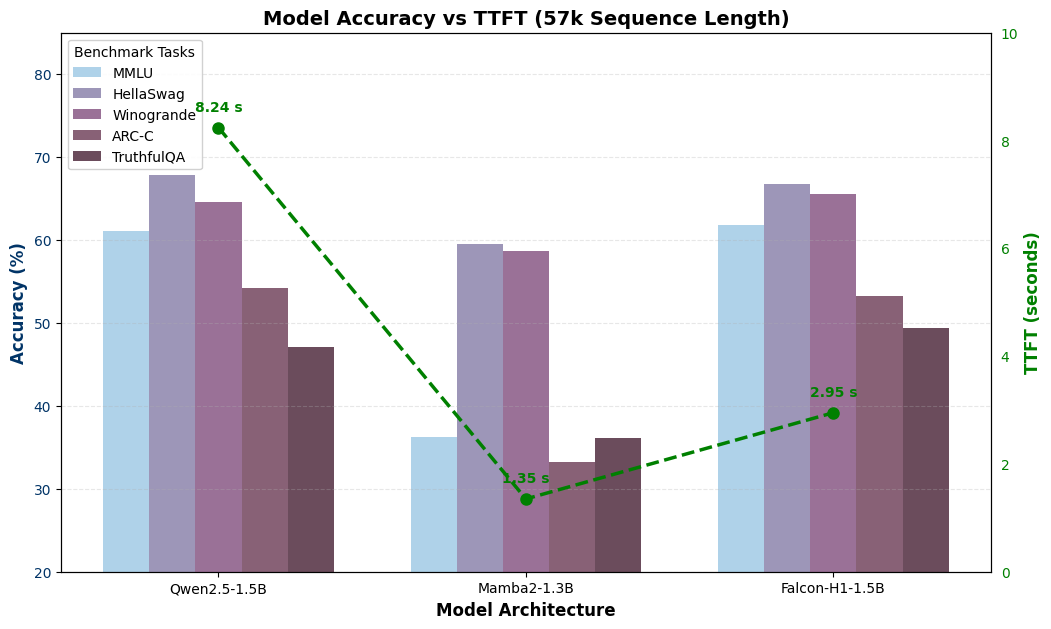

In [ ]:
# 2. Setup the Visualization
# --------------------------
# Create figure and the first axis (left side)
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- PLOT 1: Accuracy Bars (Left Axis) ---
# Group data by model and task, then plot bars
models = df['Model'].unique()
tasks = df['Task'].unique()
x = range(len(models))
bar_width = 0.15
colors = ['#AFD2E9', '#9D96B8', '#9A7197', '#886176', '#6B4C5C']

for i, task in enumerate(tasks):
    task_data = df[df['Task'] == task]
    offset = (i - len(tasks)/2 + 0.5) * bar_width
    ax1.bar([xi + offset for xi in x], task_data['Accuracy'].values, bar_width, label=task, color=colors[i])

# Customizing Axis 1 (Left)
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold', color='#003366')
ax1.set_xlabel('Model Architecture', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(20, 85)
ax1.tick_params(axis='y', labelcolor='#003366')
# ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
# ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(loc='upper left', title='Benchmark Tasks', framealpha=0.9)

# --- PLOT 2: Throughput Line (Right Axis) ---
ax2 = ax1.twinx()

ax2.plot(models_unique, ttft_vals, color='green', marker='o', markersize=8, linewidth=2.5, linestyle='--', label='TTFT (57k seq)')
ax2.set_ylabel('TTFT (seconds)', fontsize=12, fontweight='bold', color='green')

# Customizing Axis 2 (Right)
ax2.tick_params(axis='y', labelcolor='green', left=False, right=False, labelleft=False)
ax2.set_ylim(0, 10)

# Add text labels on throughput points
for i, val in enumerate(ttft_vals):
    ax2.text(i, val + 0.3, f"{val} s", color='green', ha='center', fontweight='bold')

# 3. Finalize and Show Plot
# -------------------------
plt.title('Model Accuracy vs TTFT (57k Sequence Length)', fontsize=14, fontweight='bold')


## Publication Figure

Clean version of the same plot — axis ticks, labels, and title removed for use as a paper figure. The output is saved to `{prof_dir}/accuracy_ttft.png` at 300 DPI.

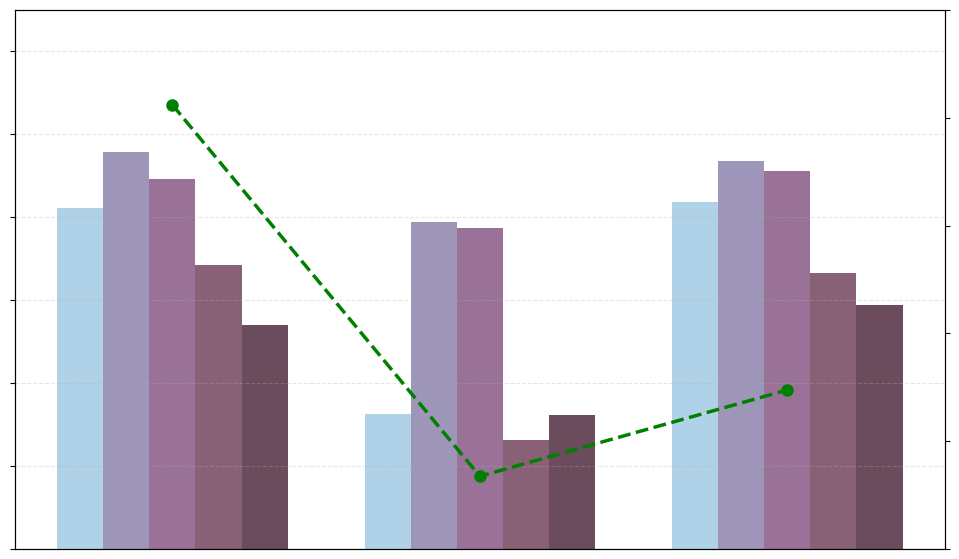

In [4]:
# 2. Setup the Visualization
# --------------------------
# Create figure and the first axis (left side)
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- PLOT 1: Accuracy Bars (Left Axis) ---
# Group data by model and task, then plot bars
models = df['Model'].unique()
tasks = df['Task'].unique()
x = range(len(models))
bar_width = 0.15
colors = ['#AFD2E9', '#9D96B8', '#9A7197', '#886176', '#6B4C5C']

for i, task in enumerate(tasks):
    task_data = df[df['Task'] == task]
    offset = (i - len(tasks)/2 + 0.5) * bar_width
    ax1.bar([xi + offset for xi in x], task_data['Accuracy'].values, bar_width, label=task, color=colors[i])

# Customizing Axis 1 (Left)
# ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold', color='#003366')
# ax1.set_xlabel('Model Architecture', fontsize=12, fontweight='bold')
# ax1.set_xticks(x)
# ax1.set_xticklabels(models)
ax1.set_ylim(20, 85)
# ax1.tick_params(axis='y', labelcolor='#003366')
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
# ax1.legend(loc='upper left', title='Benchmark Tasks', framealpha=0.9)

# --- PLOT 2: Throughput Line (Right Axis) ---
ax2 = ax1.twinx()

ax2.plot(models_unique, ttft_vals, color='green', marker='o', markersize=8, linewidth=2.5, linestyle='--', label='TTFT (57k seq)')
# ax2.set_ylabel('TTFT (seconds)', fontsize=12, fontweight='bold', color='green')

# Customizing Axis 2 (Right)
# ax2.tick_params(axis='y', labelcolor='green', left=False, right=False, labelleft=False)
ax2.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=False)
ax2.set_ylim(0, 10)

# Add text labels on throughput points
# for i, val in enumerate(ttft_vals):
#     ax2.text(i, val + 0.3, f"{val} s", color='green', ha='center', fontweight='bold')

# 3. Finalize and Show Plot
# -------------------------
# plt.title('Model Accuracy vs TTFT (57k Sequence Length)', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()
plt.savefig(f"{prof_dir}/accuracy_ttft.png",  bbox_inches='tight', dpi=300)